<a href="https://colab.research.google.com/github/lxlyp438/PyTorch_Deep_Learning_course/blob/main/02_pytorch_neural_network_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Resources
* imagenet
* Yann Lecun batch size
* tensorflow playground
* figma.com for drawing
* logit (in deep learning, tensor flow)
* madewithml.com/courses/foundations/neural-networks/ (MLOPs)
* Google python docstring guide

### Binary classification, multiclass/multi-label classification
* single label multiclass classification

* image input shape: [batch_size, colour_channels, width, height]



### Architecture of a Classification Model
* **Hyperparameters**: input layer shape (in features), hidden layer(s), neurons per hidden layer, output layer shape (out features), hidden layer activation (e.g., ReLU), output activation (e.g., Sigmoid - `torch.sigmoid`), loss function (e.g. binary crossentropy - `torch.nn.BCEloss`), optimizer (e.g., SGD, Adam, `torch.optim`)

## Make classification data and get it ready

In [ ]:
import sklearn # machine learning library for Python (e.g., toy datasets)
from sklearn.datasets import make_circles

## make 1000 samples as toy data
n_samples = 1000
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

len(X), len(y)
#print(f"First 5 samples of X: {X[:5]}, \ny: {y[:5]}")

# make dataframe of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0], # first column
                        "X2": X[:,1], # second column
                        "label": y})
circles.head(10)
print(f"data label counts: {circles.label.value_counts()}")

## Visualize
import matplotlib.pyplot as plt
'''
plt.scatter(x=X[:,0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu)
'''
# check input and output shapes
print(f"Shapes, input: {X.shape}, output: {y.shape}")

## view the first example of features and labels
X_example = X[0]
y_example = y[0]
print(f"Values for one example of X: {X_example} and y: {y_example}")
print(f"Shapes for one example of X: {X_example.shape} and y: {y_example.shape}")

## turn data into tensors (of float32) and create train and test splits
import torch
type(X)
print(f"type of X is: {type(X)}, {X.dtype}")
X = torch.from_numpy(X).type(torch.float) #float is alias of float32
y = torch.from_numpy(y).type(torch.float)
print(f"after tensor conversion, type of X is: {type(X)}, {X.dtype}")

## split data into train and test sets (randomly)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,#20%
                                                    random_state=42) #seed

## Build a model (classification)
from torch import nn
# device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

# class CircleModelV0(nn.Module):
#   def __init__(self):
#     super().__init__()

#     # create 2 nn.Linear layers capable of handling the shapes of the input data
#     # self.layer_1 = nn.Linear(in_features=2,
#     #                         out_features=5)
#     # self.layer_2 = nn.Linear(in_features=5,
#     #                         out_features=1)

#     self.two_linear_layers = nn.Sequential(
#       nn.Linear(in_features=2, out_features=5),
#       nn.Linear(in_features=5, out_features=1)
#     )

#   # define a forward()
#   def forward(self, x):
#     # return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2 -> output
#     return two_linear_layers(x)

# # instantiate a model instance
# model_0 = CircleModelV0().to(device)
# model_0
# print(f"model_0 device: {next(model_0.parameters()).device}")

## replicate the model using nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)
model_0
next(model_0.parameters()).device

# X_train = X_train.to(device)
# X_test = X_test.to(device)
# y_train = y_train.to(device)
# y_test = y_test.to(device)
# X_train.device

model_0.state_dict()

## Make predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"First 10 predictions: {untrained_preds[:10]}")
print(f"First 10 labels: {y_test[:10]}")

## set the loss function and optimizer
# nn.BCELoss() requires inputs to have gone through the sigmoid activation fcn
# prior to input to BCELoss()
# BCEwithLogitsLoss() has sigmoid activation fcn built in, numercially more stable
loss_fcn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

## calculate accuracy - out of 100 examples, what percentage does our model get right?
def accuracy_fcn(y_true, y_pred):
  #print(f"sum of correct pred: {torch.eq(y_true, y_pred).sum()}")
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

## Going from raw logits ->
## --> prediction probabilities (by sigmoid or softmax)
## --> prediction labels (by rounding or take the argmax)

## model outputs raw logits

# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
print(f"logits: \n{y_logits}")

## Use sigmoid activation funciton on the raw logits to turn them into
## prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
print(f"prediction probability: \n{y_pred_probs}")

## Find the prediction label
y_preds = torch.round(y_pred_probs)

model_0.eval()
with torch.inference_mode():
  y_preds_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))))

y_preds.shape, y_preds.squeeze().shape

## Training loop
torch.manual_seed(42) #torch.cuda.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
epoch = 0
while True:
  model_0.train()
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  #print(f"y_logits shape: {y_logits.shape}, y_train sahpe: {y_train.shape}")
  loss = loss_fcn(y_logits,
                  y_train)
  acc = accuracy_fcn(y_true=y_train,
                     y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    if epoch >= 100:
      break

    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fcn(test_logits,
                         y_test)
    test_acc = accuracy_fcn(y_true=y_test,
                            y_pred=test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Train Loss: {loss:0.5f}, Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

    epoch = epoch + 1

# Making predictions and evaluate the model
import requests
from pathlib import Path

# Download helper funcitons from github Learn PyTorch repo (if it's not already)
if Path("helper_functions.py").is_file():
  print("helper_function.py already exists, skipping downloading.")
else:
  print("downloading helper_functions.py ...")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.title("Train")
# plot_decision_boundary(model_0, X_train, y_train)
# plt.subplot(1, 2, 2)
# plt.title("Test")
# plot_decision_boundary(model_0, X_test, y_test)

## Improving a model (from a model perspective, instead of data)
# change hyperparameters of the model: number of layers, number of hiddend units/neurons, number of epochs,
# different activation functions or loss fcn or optimizer, learning rate,

class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

loss_fcn_1 = nn.BCEWithLogitsLoss()
optimizer_1 = torch.optim.SGD(params=model_1.parameters(),
                              lr=0.01)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epoch = 0
# training and testing loop
while True:
  # training
  model_1.train()
  train_logits_1 = model_1(X_train).squeeze()
  train_pred_1 = torch.round(torch.sigmoid(train_logits_1))

  train_loss_1 = loss_fcn_1(train_logits_1,
                            y_train)
  train_acc_1 = accuracy_fcn(y_true=y_train,
                           y_pred=train_pred_1)

  optimizer_1.zero_grad()
  train_loss_1.backward()
  optimizer_1.step()

  # testing
  model_1.eval()
  with torch.inference_mode():
    if epoch >= 1000:
      break

    test_logits_1 = model_1(X_test).squeeze()
    test_pred_1 = torch.round(torch.sigmoid(test_logits_1))

    test_loss_1 = loss_fcn_1(test_logits_1,
                             y_test)
    test_acc_1 = accuracy_fcn(y_true=y_test,
                              y_pred=test_pred_1)

    epoch = epoch + 1

    if (epoch % 100 == 0):
      print(f"Epoch: {epoch} | Train Loss: {loss:0.5f}, Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

# evaluating the model



# Non-linear models

## Prepare the data

In [ ]:
from sklearn.datasets import make_circles

n_samples = 1000
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)
X.shape, y.shape
# put the data into Pandas dataframe (like a table)
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                       "X2": X[:, 1],
                       "label": y
})
circles.head(10)
# check the counts of different labels
circles.label.value_counts()
circles.X1.dtype
circles.label.dtype

# import helper functions from github repo
import requests
from pathlib import Path
if Path("helper_functions.py").is_file():
  print("helper_funcitons.py already exists, skipping download.")
else:
  print("Downloading helper_functions.py ...")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary, accuracy_fn

# convert the data (currently in NumPy arrays) to PyTorch tensors
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X.shape, y.shape, X.dtype

# split data randomly into train and test datsets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)
len(X_train), len(y_train)

helper_funcitons.py already exists, skipping download.


(800, 800)

In [ ]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

# instantiate the model and put model and data onto the device
model_3 = CircleModelV2().to(device)
model_3

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

# set up loss funciton and optimizer
loss_fcn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(),
                            lr=0.1)

# training loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epoch = 0
while True:
  model_3.train()
  train_logits = model_3(X_train).squeeze()
  train_pred = torch.round(torch.sigmoid(train_logits))

  train_loss = loss_fcn(train_logits,
                        y_train)
  train_acc = accuracy_fn(y_train, train_pred)

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fcn(test_logits,
                         y_test)
    test_acc = accuracy_fn(test_pred, y_test)

  if (epoch >= 10000):
    break
  elif (epoch % 1000 == 0):
    print(f"Epoch: {epoch} | Train Loss: {train_loss:.5f}, Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

  epoch = epoch + 1

# visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)


# Multiclass classification

Epoch: 0 | Train Loss: 1.15883 | Test Loss: 1.07554
Epoch: 100 | Train Loss: 0.03312 | Test Loss: 0.02433
Epoch: 200 | Train Loss: 0.02657 | Test Loss: 0.01651
Epoch: 300 | Train Loss: 0.02503 | Test Loss: 0.01440
Epoch: 400 | Train Loss: 0.02427 | Test Loss: 0.01335
Epoch: 500 | Train Loss: 0.02377 | Test Loss: 0.01269
Epoch: 600 | Train Loss: 0.02339 | Test Loss: 0.01218
Epoch: 700 | Train Loss: 0.02307 | Test Loss: 0.01179
Epoch: 800 | Train Loss: 0.02279 | Test Loss: 0.01147
Epoch: 900 | Train Loss: 0.02253 | Test Loss: 0.01120
Epoch: 1000 | Train Loss: 0.02230 | Test Loss: 0.01095


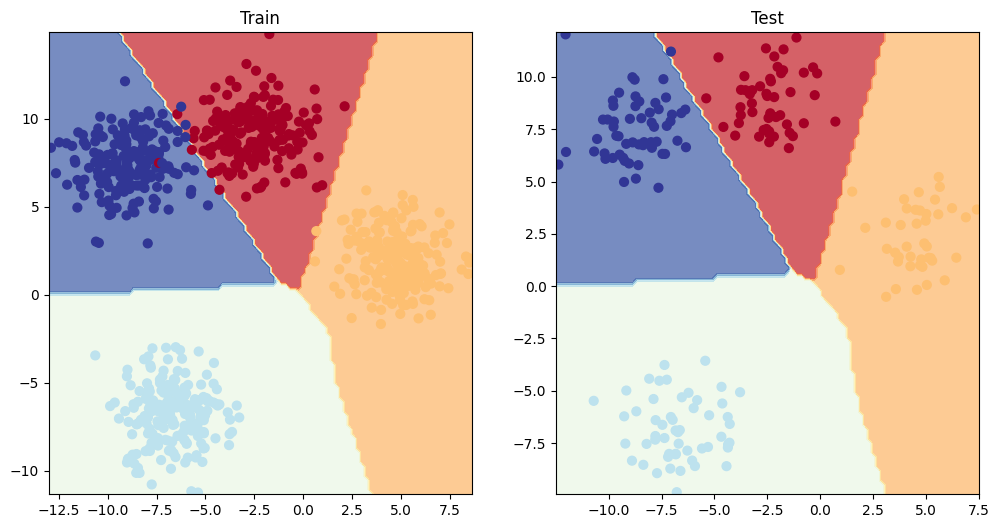

In [ ]:
# creating toy data
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

import requests
from pathlib import Path
if Path("helper_funcitons.py").is_file():
  print("helper_functions.py already exists, skipping download.")
else:
  print("Downloading helper_funcitons.py ...")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary, accuracy_fn

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"

X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5, # add noise to the clusters
                            random_state=RANDOM_SEED)

# covert the data (in NumPy) into tensor format
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
X_blob.shape, y_blob.shape

# split the data into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)
X_blob_train.shape

# plt.figure(figsize=(10, 7))
# plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

X_blob_train, X_blob_test = X_blob_train.to(device), X_blob_test.to(device)
y_blob_train, y_blob_test = y_blob_train.to(device), y_blob_test.to(device)

torch.unique(y_blob_train) # get the unique values/classes in the y_blob_train

from torch import nn
# multi-class classification model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    """Initialize multi-class classification model.

    Args:
      input_features (int): number of input features to the model
      output_features (int): number of output features (number of output classes)
      hidden_units (int): number of hidden units between layers, default 8

    Returns:

    Example:

    """
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
      nn.Linear(in_features=input_features, out_features=hidden_units),
      nn.ReLU(),
      nn.Linear(in_features=hidden_units, out_features=hidden_units),
      nn.ReLU(),
      nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

# create an instance of the BlobModel and send it to the target device
model_4 = BlobModel(input_features=NUM_FEATURES,
                    output_features=NUM_CLASSES,
                    hidden_units=8).to(device)
model_4

# loss function and optimizer
loss_fcn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.1)

# build a training loop
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

epoch = 0
while True:
  model_4.train()
  train_logits = model_4(X_blob_train) # why no squeeze()?
  train_pred = torch.softmax(train_logits, dim=1).argmax(dim=1)

  train_loss = loss_fcn(train_logits, y_blob_train)
  #acc_train = accuracy_fn()

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_blob_test)
    test_pred = torch.argmax(torch.softmax(test_logits, dim=1), dim=1)

    test_loss = loss_fcn(test_logits, y_blob_test)

  if epoch > 1000:
    break
  elif epoch % 100 == 0:
    print(f"Epoch: {epoch} | Train Loss: {train_loss:.5f} | Test Loss: {test_loss:.5f}")

  epoch = epoch + 1


model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test)

y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_labels = torch.argmax(y_pred_probs, dim=1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)



## Classification Metrics for evaluation
* **Accuracy** [torchmetrics.Accuracy(), sklearn.metrics.accuracy_score()], for balanced classes/datasets
* **Precision** [torchmetrics.Precision(), sklearn.metrics.precision_score()], higher precision -> less false positive
* **Recall** [torchmetrics.Recall(), sklearn.metrics.recall_score()], higher recall -> less false negative
* **F1-score** [torchmetrics.F1Score(), sklearn.metrics.f1_score()], combination of Precision and Recall
* **Confusion matrix** [torchmetrics.ConfusionMatrix()]
* **Classification report** [scikit learn]

- need to import torchmetrix

- Beyond accuracy article

In [ ]:
!pip install torchmetrics

In [ ]:
from torchmetrics import Accuracy

torchmetrics_accuracy = Accuracy(task="multiclass", num_classes=4).to(device)

torchmetrics_accuracy(y_pred_labels, y_blob_test)


tensor(0.9950, device='cuda:0')